In [31]:
from __future__ import annotations
import os
import pandas as pd
from spread_adf_kss import (
    kss_table_for_alts,
    read_copula_top2,
    result_adf_kss_dir,
    run_full_pipeline,
)

TF = "1h"

## 1. symbol selection

we have the data:
- $B_t$: `BTC_USDT` close
- $P_t^{(i)}$: close of altcoin $i$

For each altcoin $i$, fit
$
B_t = \beta_i P_t^{(i)} + \varepsilon_t^{(i)}
$
Then spread (i.e. residual)
$
S_t^{(i)} = B_t - \hat\beta_i P_t^{(i)} = \hat\varepsilon_t^{(i)}.
$

For each spread, run the KSS-style Taylor auxiliary regression:

$$
\Delta S_t^{(i)} = \delta_i\big(S_{t-1}^{(i)}\big)^3 + u_t.
$$

$$
\text{pass KSS} \iff t(\hat\delta_i) < -1.92. \text{(At 10\% level)}
$$



Then for each pair $(BTC, i)$, compute Kendall rank correlation on aligned closes:

$$
\tau_i = \tau(B_t, P_t^{(i)}).
$$

Kendall correlation measures rank-consistency (monotonic dependence), and we prefer it over Pearson because crypto returns are often non-Gaussian with outliers/nonlinearity, where linear correlation can be unstable or misleading.

Current selection rule is:
1. keep only symbols with `kss_pass_10pct = True`;
2. rank by `kendall_tau` descending, and select top 2 symbols as Copula candidates.

In [32]:
summary_path = os.path.join(result_adf_kss_dir(TF), "spread_adf_kss_summary.csv")
cols = [
    "alt_symbol",
    "kendall_tau",
    "adf_statistic",
    "adf_pvalue",
    "adf_used_lags",
    "adf_pass_5pct",
    "kss_t_stat",
    "kss_pass_10pct",
]
display(pd.read_csv(summary_path)[cols])

,alt_symbol,kendall_tau,adf_statistic,adf_pvalue,adf_used_lags,adf_pass_5pct,kss_t_stat,kss_pass_10pct
0,ADA_USDT,0.291216,-0.819511,0.813323,53,False,-2.290940,True
1,BCH_USDT,0.555962,-2.239289,0.192296,54,False,-5.953640,True
2,ETC_USDT,0.003135,-1.857445,0.352337,55,False,-6.797596,True
3,ETH_USDT,0.586205,-1.334392,0.613295,52,False,-1.494605,False
4,LINK_USDT,0.427718,-1.505115,0.530980,54,False,-4.045046,True
5,LTC_USDT,0.284595,-1.328941,0.615830,53,False,-3.748960,True
6,XRP_USDT,0.624554,-2.771797,0.062417,55,False,-2.397124,True


*We will run copula model on XRP/BCH.*

In [33]:
from spread_adf_kss import discover_csv_paths, load_close_series, merge_on_timestamp

paths = discover_csv_paths("1h")
pair_hour_df = merge_on_timestamp(
    {
        "XRP_USDT": load_close_series(paths["XRP_USDT"]),
        "BCH_USDT": load_close_series(paths["BCH_USDT"]),
    }
).reset_index().rename(columns={"index": "timestamp"})

# 2. Copula
- fit marginals first, then apply transformation to get $(u_t, v_t) \in (0,1)^2$;

For the selected symbols `XRP_USDT` and `BCH_USDT`, we use the BTC-reference spreads from the previous step:

$$
S_t^{XRP} = B_t - \hat\beta_{XRP}P_t^{XRP}, \qquad
S_t^{BCH} = B_t - \hat\beta_{BCH}P_t^{BCH}.
$$

For each spread $S_t^{(j)}$, fit candidate marginal distributions $F_j(\cdot;\theta_j)$:

$$
F_j \in \{\text{Normal}, \text{Student-t}, \text{Cauchy}\}.
$$

The parameters are estimated by maximum likelihood:

$$
\hat\theta_j = \arg\max_{\theta_j}\sum_{t=1}^{T}\log f_j(S_t^{(j)};\theta_j).
$$

Then select the best marginal by AIC:

$$
\text{AIC}_j = 2k_j - 2\sum_{t=1}^{T}\log f_j(S_t^{(j)};\hat\theta_j).
$$

Finally, apply the probability integral transform (PIT):

$$
u_t = \hat F_{XRP}(S_t^{XRP}), \qquad
v_t = \hat F_{BCH}(S_t^{BCH}),
$$

so that $(u_t, v_t) \in (0,1)^2$ and can be used as the input for copula fitting.


In [34]:
from copula_marginals import fit_marginals_and_transform

COPULA_SYMBOLS = ["XRP_USDT", "BCH_USDT"]
uv_df, fit_summary, spread_meta = fit_marginals_and_transform(TF, COPULA_SYMBOLS)

display(spread_meta)
display(fit_summary)
display(uv_df.head())

,alt_symbol,spread_column,beta,r_squared,n_obs
0,XRP_USDT,XRP_USDT_spread,44696.380011,0.900521,43824
1,BCH_USDT,BCH_USDT_spread,132.537764,0.807578,43824


,spread_column,distribution,params,n_params,log_likelihood,aic,best
0,BCH_USDT_spread,student_t,"{'df': 3.525279158235672, 'loc': 6590.23042549...",3,-506337.479769,1.012681e+06,True
1,BCH_USDT_spread,cauchy,"{'loc': 5854.630160138376, 'scale': 10695.6183...",2,-508379.467465,1.016763e+06,False
2,BCH_USDT_spread,normal,"{'loc': 5519.032438097499, 'scale': 26566.2190...",2,-508635.992626,1.017276e+06,False
3,XRP_USDT_spread,student_t,"{'df': 2.484639454141731, 'loc': 5979.13625537...",3,-489959.697093,9.799254e+05,True
4,XRP_USDT_spread,normal,"{'loc': 8645.371579389881, 'scale': 17489.1832...",2,-490315.024921,9.806340e+05,False
5,XRP_USDT_spread,cauchy,"{'loc': 5570.750477216465, 'scale': 6950.26292...",2,-491092.936922,9.821899e+05,False


,timestamp,XRP_USDT_spread,BCH_USDT_spread,u,v
0,1609459200000,19084.212552,-16244.389586,0.827258,0.148476
1,1609462800000,19408.050154,-16961.212846,0.832062,0.142194
2,1609466400000,19191.350154,-17766.380517,0.828864,0.135451
3,1609470000000,19119.312824,-17216.772966,0.827786,0.140018
4,1609473600000,18516.256263,-16900.438828,0.818476,0.142716


- fit copulas (Gaussian, Student-t, Clayton, Gumbel, Frank) via MLE, select the best by AIC;

After marginal fitting, the transformed observations $(u_t, v_t)$ are approximately uniform on $(0,1)^2$. A copula models their dependence structure separately from the marginal distributions:

$$
C(u,v;\theta)=\Pr(U\le u, V\le v).
$$

For each candidate copula family, estimate parameters by maximizing the copula log-likelihood:

$$
\hat\theta = \arg\max_\theta \sum_{t=1}^{T}\log c(u_t,v_t;\theta),
$$

where $c(u,v;\theta)=\frac{\partial^2 C(u,v;\theta)}{\partial u\partial v}$ is the copula density.

We compare the following candidate copulas:

$$
C \in \{\text{Gaussian}, \text{Student-t}, \text{Clayton}, \text{Gumbel}, \text{Frank}\}.
$$

The best copula is selected by the smallest AIC:

$$
\text{AIC}=2k-2\sum_{t=1}^{T}\log c(u_t,v_t;\hat\theta).
$$

In [35]:
from copula_fitting import fit_copulas_and_select

copula_summary, best_copula = fit_copulas_and_select(uv_df)

display(copula_summary)
best_copula

,copula,params,n_params,log_likelihood,aic,success,message,best
0,student_t,"{'rho': -0.25179678980781806, 'df': 4.42092561...",2,1420.797481,-2837.594962,True,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH,True
1,frank,{'theta': -1.5218065564080216},1,1178.452133,-2354.904266,True,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH,False
2,gaussian,{'rho': -0.18887495209337987},1,791.065560,-1580.131120,True,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH,False
3,clayton,{'theta': 0.001},1,-2.146398,6.292795,True,CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL,False
4,gumbel,{'theta': 1.001},1,-17.150940,36.301880,True,CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL,False


{'copula': 'student_t',
 'params': {'rho': -0.25179678980781806, 'df': 4.420925610617675},
 'n_params': 2,
 'log_likelihood': 1420.7974807985397,
 'aic': -2837.5949615970794,
 'success': True,
 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH',
 'best': True}

,copula,aic,best
0,student_t,-2837.594962,True
1,frank,-2354.904266,False
2,gaussian,-1580.131120,False
3,clayton,6.292795,False
4,gumbel,36.301880,False


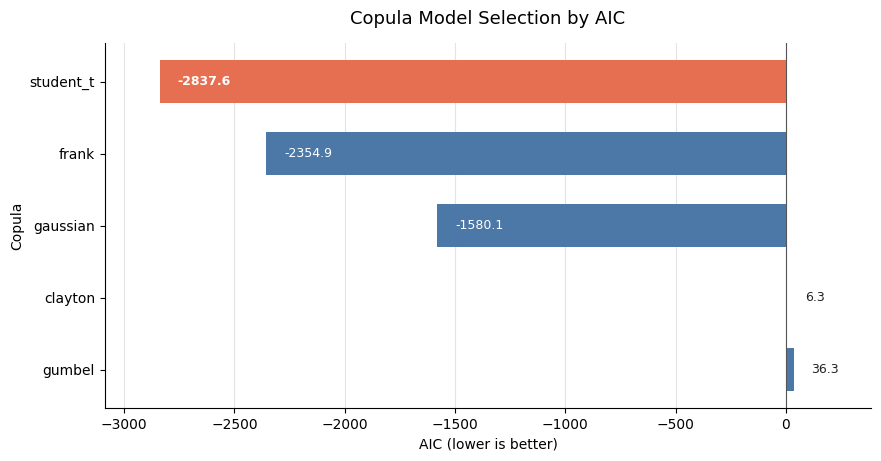

In [37]:
import matplotlib.pyplot as plt

aic_df = copula_summary[["copula", "aic", "best"]].sort_values("aic").reset_index(drop=True)
display(aic_df)

colors = ["#e76f51" if is_best else "#4c78a8" for is_best in aic_df["best"]]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(aic_df["copula"], aic_df["aic"], color=colors, height=0.6)

ax.set_title("Copula Model Selection by AIC", fontsize=13, pad=14)
ax.set_xlabel("AIC (lower is better)")
ax.set_ylabel("Copula")
ax.axvline(0, color="#555555", linewidth=0.8)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for idx, (bar, aic) in enumerate(zip(bars, aic_df["aic"])):
    if aic < 0:
        x_text = aic + 80
        ha = "left"
        color = "white"
    else:
        x_text = aic + 80
        ha = "left"
        color = "#222222"
    ax.annotate(
        f"{aic:.1f}",
        xy=(x_text, bar.get_y() + bar.get_height() / 2),
        ha=ha,
        va="center",
        color=color,
        fontsize=9,
        fontweight="bold" if aic_df.loc[idx, "best"] else "normal",
    )

ax.set_xlim(aic_df["aic"].min() - 250, max(250, aic_df["aic"].max() + 350))
ax.invert_yaxis()
plt.tight_layout(pad=1.4)
plt.show()

- computational efficiency of Nelder-Mead vs BFGS.

# 3. Mispricing Index / Trading signal
- compute MI from copula conditional CDFs (e.g., $\partial C(u_1,u_2)/\partial u_2$ and $\partial C(u_1,u_2)/\partial u_1$), then center as $MI=\text{conditional prob}-0.5$;
- generate entry/exit signals by MI thresholds, backtest and display signals on the price plot.